# Spatial Channel Tuning Functions (CTF) Analysis

## Part of the open_dvm Toolbox

Channel Tuning Functions (CTF) apply an inverted encoding model (IEM) to reconstruct how EEG channels jointly encode a continuous stimulus feature — here, spatial position. This tutorial examines spatial selectivity across frequency bands (broadband, alpha), power types (evoked vs. total), and task contexts (localizer vs. main task).

## Learning Objectives

After completing this tutorial, you will:

- **Compute a spatial CTF** — Reconstruct spatial tuning functions from EEG channel activity via an inverted encoding model
- **Compare frequency bands** — Contrast broadband voltage tuning against alpha-band oscillatory tuning
- **Distinguish evoked and total power** — Separate phase-locked from non-phase-locked contributions to alpha tuning
- **Test cross-task generalization** — Assess whether a CTF trained on one task transfers to another
- **Visualize tuning across frequencies** — Build a time-frequency map of spatial selectivity

**Prerequisites:** This tutorial assumes familiarity with the localizer/main task structure introduced in `05_bdm_decoding.ipynb`.

## Overview

### Key Steps
1. **Broadband spatial tuning**: Compute and visualize a CTF from raw (unfiltered) voltage
2. **Alpha-band spatial tuning**: Compare evoked vs. total alpha power tuning
3. **Cross-task generalization**: Train on localizer, test on main task
4. **Multi-frequency analysis** (optional): Map spatial tuning across a frequency range

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
%matplotlib inline

import sys, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

warnings.filterwarnings('ignore')
sys.path.insert(0, '/Users/dvm/Documents/DvM')

from open_dvm.analysis import CTF
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_ctf_timecourse

print("✓ Imports successful")

✓ Imports successful


### 1.2 Load Preprocessed Data with Eye-Tracking Quality Control

In [2]:
# Configuration
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)
sj = 2

eye_dict = {
    'use_tracker': True, 'window_oi': (0, 0.3), 'angle_thresh': 1,
    'viewing_dist': 70, 'screen_res': (1920, 1080), 'screen_h': 29,
    'drift_correct': (-0.2, 0)
}

df, epochs = FolderStructure().load_processed_epochs(sj, 'ses_01_main', 'main', eye_dict)

print(f'✓ Subject {sj} loaded: {len(epochs)} trials, {epochs.info["nchan"]} channels')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
✓ Subject 2 loaded: 2148 trials, 39 channels


---

## Section 2: Broadband Spatial Tuning

**Question**: How selective is EEG activity for spatial position, using raw (unfiltered) voltage?

**Approach**: Compute a CTF using broadband (unfiltered) data and visualize both the 2D tuning profile and its slope timecourse.

In [3]:
# Initialize and compute broadband CTF
ctf_localizer = CTF(
    sj=sj, epochs=epochs, df=df, to_decode='img_loc',  # Reconstruct tuning for spatial position (img_loc)
    nr_bins=8,            # 8 discrete position bins (matches 8 possible stimulus locations)
    nr_chans=8,           # 8 hypothetical spatial channels underlying the basis set
    elec_oi='all',        # Use all electrodes
    filter=8,             # Lowpass filter at 8 Hz for broadband voltage reconstruction
    avg_ch=True,          # Average tuning across bins (not per-bin reconstruction)
    baseline=(-0.2, 0),   # Baseline correction: -200 to 0 ms
    downsample=128        # Downsample to 128 Hz
)

ctfs, ctf_params, _ = ctf_localizer.spatial_ctf(
    pos_labels='all',                     # Use all position bins
    cnds=dict(block_type=['localizer']),  # Localizer trials only
    window_oi=(-0.2, 0.5),                # Analysis window: -200 to 500 ms
    freqs='broadband'                     # Broadband (unfiltered) voltage reconstruction
)

print("✓ Broadband CTF computed")

Creating bassiset with sin_power  7
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 845 samples (1.650 s)

Frequency 1 out of 1
Applying baseline correction (mode: mean)
Running ctf for localizer condition
get ctf tuning params
✓ Broadband CTF computed


Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


/var/folders/jd/_5gm34_n44x5fnp2_hdy7_1m0000gn/T/ipykernel_1739/1206241485.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


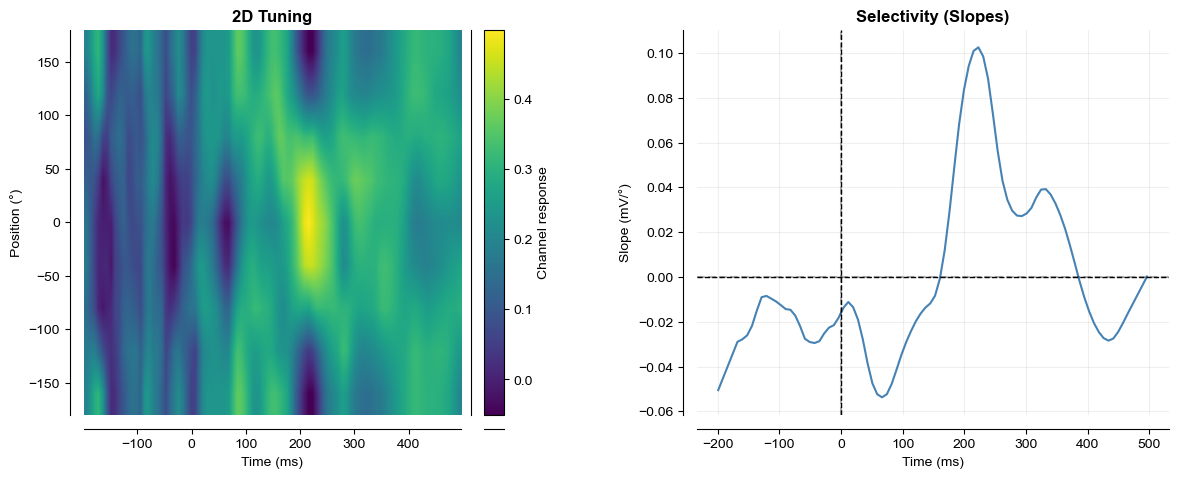

✓ Broadband visualization complete


In [4]:
# Visualize broadband
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
plt.sca(ax1)
plot_ctf_timecourse(ctfs, cnds=['localizer'], timecourse='2d_ctf',
                    output='C2_voltage', stats=None, smooth=True)
ax1.set_title('2D Tuning', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Position (°)')

ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)
plot_ctf_timecourse(ctf_params, cnds=['localizer'], colors=['steelblue'],
                    output='voltage_slopes', smooth=True, show_legend=False)
ax2.set_title('Selectivity (Slopes)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Slope (mV/°)')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Broadband visualization complete")

---

## Section 3: Alpha-Band Spatial Tuning (Evoked vs. Total Power)

**Question**: Does an oscillatory (alpha-band) mechanism carry spatial information distinct from broadband voltage? Is it driven by phase-locked (evoked) or non-phase-locked (total) activity?

**Approach**: Filter to the alpha band (8–12 Hz), compute both evoked and total power CTFs, and compare all three tuning profiles (broadband, alpha evoked, alpha total) side by side.

In [5]:
# Compute alpha-band CTF
ctfs_alpha, ctf_params_alpha, _ = ctf_localizer.spatial_ctf(
    pos_labels='all',                     # Use all position bins
    cnds=dict(block_type=['localizer']),  # Localizer trials only
    window_oi=(-0.2, 0.5),                # Analysis window: -200 to 500 ms
    freqs=dict(alpha=[8, 12])             # Band-pass filter 8-12 Hz (alpha), evoked + total power
)

print("✓ Alpha CTF computed")

Creating bassiset with sin_power  7
Frequency 1 out of 1
Setting up band-pass filter from 8 - 12 Hz

IIR filter parameters
---------------------
butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 8.00, 12.00 Hz: -6.02, -6.02 dB

Running ctf for localizer condition
get ctf tuning params
✓ Alpha CTF computed


Times converted from seconds to milliseconds
Times converted from seconds to milliseconds
Times converted from seconds to milliseconds


/var/folders/jd/_5gm34_n44x5fnp2_hdy7_1m0000gn/T/ipykernel_1739/762496326.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


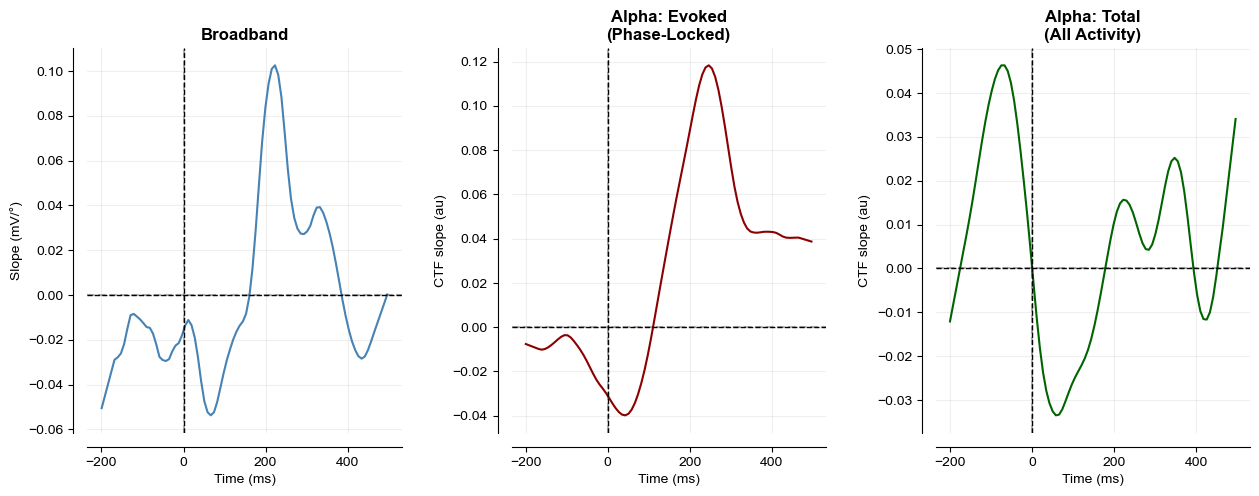

✓ Three-way comparison complete

Key observations:
  • Are evoked and total similar or different?
  • Stronger/weaker selectivity in total power?
  • Transient or sustained mechanism?


In [6]:
# 3-panel comparison: Broadband vs Alpha Evoked vs Alpha Total
plt.close('all')

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.35)

# Panel 1: Broadband
ax1 = fig.add_subplot(gs[0, 0])
plt.sca(ax1)
plot_ctf_timecourse(ctf_params, cnds=['localizer'], colors=['steelblue'],
                    output='voltage_slopes', smooth=True, show_legend=False, stats=None)
ax1.set_title('Broadband', fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope (mV/°)')
ax1.axhline(0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.2)

# Panel 2: Alpha Evoked
ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)
plot_ctf_timecourse(ctf_params_alpha, cnds=['localizer'], colors=['darkred'],
                    output='E_slopes', smooth=True, show_legend=False, stats=None)
ax2.set_title('Alpha: Evoked\n(Phase-Locked)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.2)

# Panel 3: Alpha Total
ax3 = fig.add_subplot(gs[0, 2])
plt.sca(ax3)
plot_ctf_timecourse(ctf_params_alpha, cnds=['localizer'], colors=['darkgreen'],
                    output='T_slopes', smooth=True, show_legend=False, stats=None)
ax3.set_title('Alpha: Total\n(All Activity)', fontsize=12, fontweight='bold')
ax3.axhline(0, color='k', linestyle='--', alpha=0.3)
ax3.axvline(0, color='k', linestyle='--', alpha=0.3)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Three-way comparison complete")
print("\nKey observations:")
print("  • Are evoked and total similar or different?")
print("  • Stronger/weaker selectivity in total power?")
print("  • Transient or sustained mechanism?")

---

## Section 4: Cross-Task Generalization

**Question**: Does a spatial CTF trained on localizer trials generalize to the main task, where spatial position is task-irrelevant?

**Approach**: Use the `cnds` cross-condition syntax to train on localizer trials and test on main task trials.

In [7]:
# Compute generalization: localizer → main task
ctfs_cross, ctf_params_cross, _ = ctf_localizer.spatial_ctf(
    pos_labels='all',                                 # Use all position bins
    cnds=dict(block_type=[['localizer'], ['main']]),  # Train on localizer, test on main
    window_oi=(-0.2, 0.5),                            # Analysis window: -200 to 500 ms
    freqs='broadband'                                 # Broadband (unfiltered) voltage reconstruction
)

print("✓ Generalization computed")

Creating bassiset with sin_power  7
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 845 samples (1.650 s)

Frequency 1 out of 1
Applying baseline correction (mode: mean)
Running ctf for localizer_main condition
get ctf tuning params
✓ Generalization computed


Times converted from seconds to milliseconds


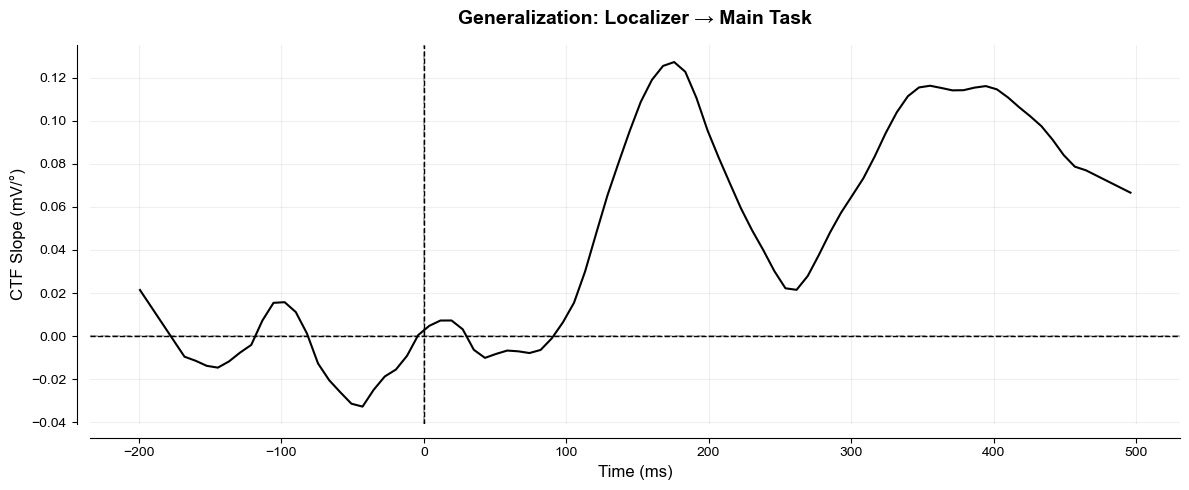

✓ Generalization visualization complete


In [8]:
# Visualize generalization
fig = plt.figure(figsize=(12, 5))
plt.sca(fig.gca())

plot_ctf_timecourse(ctf_params_cross, cnds=['localizer_main'], colors=['black'],
                    output='voltage_slopes', smooth=True, show_legend=False, stats=None)

plt.title('Generalization: Localizer → Main Task', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('CTF Slope (mV/°)', fontsize=12)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Generalization visualization complete")

---

## Section 5: Multi-Frequency Analysis (Optional, 2–30 Hz)

**Question**: Across which frequencies is spatial tuning strongest, and how does it evolve over time?

**Approach**: Compute a CTF across a range of frequencies (2–30 Hz) and visualize tuning strength as a 2D time × frequency map.

In [9]:
# Initialize multi-frequency CTF
ctf_tfr = CTF(
    sj=sj, epochs=epochs, df=df, to_decode='img_loc',  # Reconstruct tuning for spatial position (img_loc)
    nr_bins=8,            # 8 discrete position bins (matches 8 possible stimulus locations)
    nr_chans=8,           # 8 hypothetical spatial channels underlying the basis set
    elec_oi='all',        # Use all electrodes
    filter=8,             # Lowpass filter cutoff (unused when freqs='main_param' below)
    avg_ch=True,          # Average tuning across bins (not per-bin reconstruction)
    baseline=(-0.2, 0),   # Baseline correction: -200 to 0 ms
    downsample=128,       # Downsample to 128 Hz
    min_freq=2,           # Lowest frequency in the multi-frequency sweep (Hz)
    max_freq=30,          # Highest frequency in the multi-frequency sweep (Hz)
    num_frex=10,          # 10 frequencies between 2-30 Hz
    freq_scaling='linear' # Linearly spaced frequency steps
)

_, ctf_params_tfr, _ = ctf_tfr.spatial_ctf(
    pos_labels='all',                     # Use all position bins
    cnds=dict(block_type=['localizer']),  # Localizer trials only
    window_oi=(-0.2, 0.5),                # Analysis window: -200 to 500 ms
    freqs='main_param'                    # Sweep across the configured multi-frequency range
)

print("✓ Multi-frequency CTF computed")

Creating bassiset with sin_power  7
Frequency 1 out of 9
Setting up band-pass filter from 2 - 5.1 Hz

IIR filter parameters
---------------------
butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 2.00, 5.11 Hz: -6.02, -6.02 dB

Running ctf for localizer condition
Frequency 2 out of 9
Setting up band-pass filter from 5.1 - 8.2 Hz

IIR filter parameters
---------------------
butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 5.11, 8.22 Hz: -6.02, -6.02 dB

Running ctf for localizer condition
Frequency 3 out of 9
Setting up band-pass filter from 8.2 - 11 Hz

IIR filter parameters
---------------------
butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 8.22, 11.33 Hz: -6.02, -6.02 dB

Running ctf for

Times converted from seconds to milliseconds


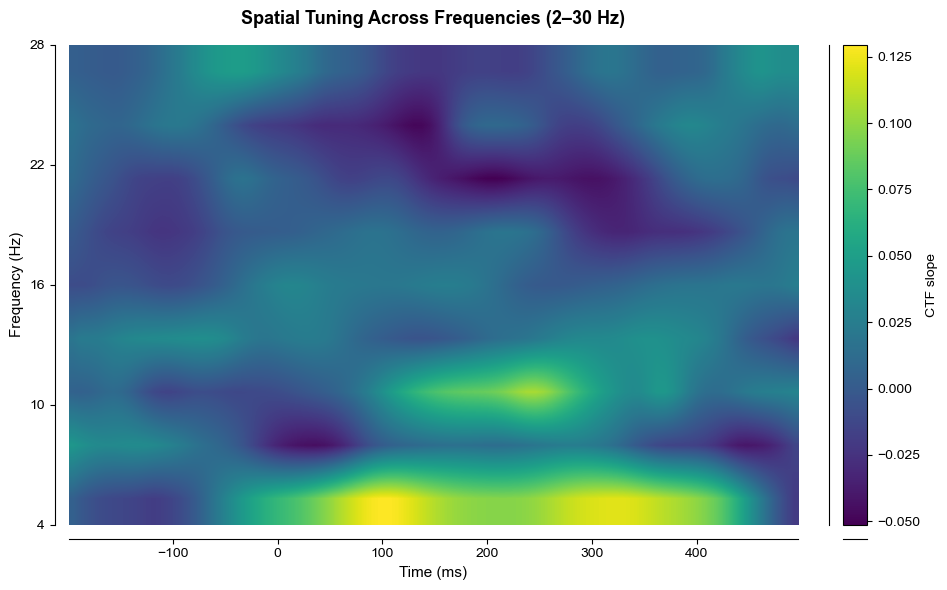

✓ Multi-frequency visualization complete


In [10]:
# Visualize frequency × time
fig = plt.figure(figsize=(10, 6))
plt.sca(fig.gca())

plot_ctf_timecourse(ctf_params_tfr, cnds=['localizer'], colors=['black'],
                    output='E_slopes', timecourse='2d_tfr', smooth=True)

plt.title('Spatial Tuning Across Frequencies (2–30 Hz)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Time (ms)', fontsize=11)
plt.ylabel('Frequency (Hz)', fontsize=11)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Multi-frequency visualization complete")

---

## Section 6: Summary and Next Steps

### Key Finding
Spatial attention operates through:
1. Multivariate EEG patterns (broadband)
2. Oscillatory modulation (alpha)
3. Stable representations that transfer across tasks

### Next Steps
- See `08_ctf_advanced.ipynb` for CTF analysis on homogeneous "ping" displays and per-subject alignment to a hypothesized reference location.